In [1]:
import pandas as pd
import numpy as np

DATA DESCRIPTION
```
file name -> Columns
quater-i.csv -> ['order_id', 'quantity', 'item_id', 'choice_description_id' 'item_price']
items.csv -> ['item_id', 'item_name']
```
Dataset Link - https://drive.google.com/drive/folders/1Z0kaFybvgFeczeUj4dldUnhTdloLqLsL?usp=share_link

In [2]:
# import like this
items_path = 'items.csv'
q1_path = 'quater-1.csv'
q2_path = 'quarter-2.csv'
q3_path = 'quarter-3.csv'



q1= pd.read_csv(q1_path)
q2 = pd.read_csv(q2_path)
q3 = pd.read_csv(q3_path)

items = pd.read_csv(items_path)


###`Q:1-5`
1. You are given three quater files, your job is to append these three files and make a single dataframe.
2. Have a index as Q-1 Q-2 Q-3 for respective quater files in the dataframe
3. Your are given a file items.csv which has item_id and item_name. Find out most sold items in each quarter.
4. Find out items which has made most revenue in each quarter.
5. Find out avg order price of each quarter.

***Note: item_price is given as str with $ sign, in earlier task you have converted this to rupees, here too first convert item_price field in rupees.***

In [5]:
# Question 1 and 2 complete 
#all_quarter = pd.concat([q1,q2,q3],keys=['Q1','Q2','Q3'])
all_quarter = pd.concat([q1,q2,q3],keys=['Q1','Q2','Q3']).reset_index()
all_quarter

,level_0,level_1,order_id,quantity,item_id,choice_description_id,item_price
0,Q1,0,1,1,1,1,$3.39
1,Q1,1,1,1,2,2,$3.39
2,Q1,2,2,2,4,3,$16.98
3,Q1,3,4,1,7,6,$9.25
4,Q1,4,6,1,9,8,$8.75
...,...,...,...,...,...,...,...
4617,Q2,2342,1829,1,23,92,$11.25
4618,Q2,2343,1830,1,23,1043,$11.25
4619,Q2,2344,1832,1,10,116,$8.75
4620,Q2,2345,1832,1,8,0,$4.45


In [ ]:
# little bit do data cleaning in item price
# string sa float banana hoga
all_quarter.rename(columns={'level_0':'Quarter'},inplace=True)
# tarika 1
all_quarter['item_price']= all_quarter['item_price'].str.split('$').apply(lambda x:x[-1]).astype(np.float64)
# tarika 2 
# all_quarter['item_price']= all_quarter['item_price'].apply(lambda x: float(x[1:]))

In [12]:

# promblems ha agar Quantity two tha tho var par one item ha price ha usa bhi tik karo
all_quarter['total_item_price'] = all_quarter['quantity'] * all_quarter['item_price']
all_quarter

,Quarter,level_1,order_id,quantity,item_id,choice_description_id,item_price,total_item_price
0,Q1,0,1,1,1,1,3.39,3.39
1,Q1,1,1,1,2,2,3.39,3.39
2,Q1,2,2,2,4,3,16.98,33.96
3,Q1,3,4,1,7,6,9.25,9.25
4,Q1,4,6,1,9,8,8.75,8.75
...,...,...,...,...,...,...,...,...
4617,Q2,2342,1829,1,23,92,11.25,11.25
4618,Q2,2343,1830,1,23,1043,11.25,11.25
4619,Q2,2344,1832,1,10,116,8.75,8.75
4620,Q2,2345,1832,1,8,0,4.45,4.45


In [ ]:
# Question 3

all_items_df = all_quarter.merge(items,how='inner',on='item_id')
# as_index= flase same kam karta ha reset_index ka tar 
# fir sort kar do quantiy ka basis par descending
# abb aap drop duplicates on the basis of quarter kar diya kyuki quarter ma bhut sara item hoga
# lakin first wala ko drop mat karna usa rakan 
all_items_df.groupby(by=['Quarter','item_name'],as_index=False)['quantity'].count().sort_values('quantity',ascending=False).drop_duplicates(subset = 'Quarter',keep='first')
# question 3 complete 

,Quarter,item_name,quantity
65,Q2,Chicken Bowl,375
17,Q1,Chicken Bowl,351


In [ ]:
# q4
items_price = all_items_df.groupby(['Quarter','item_name'],as_index=False)['total_item_price'].sum()
# then sort and drop duplicates 
items_price.sort_values('total_item_price',ascending=False).drop_duplicates(subset = 'Quarter',keep='first')

,Quarter,item_name,total_item_price
65,Q2,Chicken Bowl,4192.25
17,Q1,Chicken Bowl,3852.38


In [ ]:
# ques 5  avg order price of each order
all_items_df.groupby(['Quarter','order_id'],as_index=False)['total_item_price'].sum().groupby('Quarter')['total_item_price'].mean()
#all_items_df
# har ek quarter ma har ek order ka average price 13 dollar tha 

Quarter
Q1    13.809488
Q2    13.279828
Name: total_item_price, dtype: object

###`Q-6` From the IPL wala dataset you have to find the Purple cap holder each season.

*Note: Bowler with most no wickets in a season gets purple cap. If more than one bowler have same no of wickets in the season, one with least ecomnomy among them is purple cap holder.*

Bowler's Economy = runs-conceded per six balls

In [ ]:
# season ka data mathces ma 
# aor ball by ball data deleier ma 

matches = pd.read_csv(r'C:\Users\sumit\My_code_files\Data Science codes\week 6 - pandas\ipl-matches.csv')
delivers= pd.read_csv(r'C:\Users\sumit\My_code_files\Data Science codes\week 7 - advance pandas\ipl_deliveries.csv')
ipl_df = matches.merge(delivers,on='ID')
ipl_df

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,...,batsman_run,extras_run,total_run,non_boundary,isWicketDelivery,player_out,kind,fielders_involved,BattingTeam,BowlingTeam
0,1312200,Ahmedabad,2022-05-29,2022,Final,Rajasthan Royals,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,...,0,0,0,0,0,NaN,NaN,NaN,Rajasthan Royals,Gujarat Titans
1,1312200,Ahmedabad,2022-05-29,2022,Final,Rajasthan Royals,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,...,0,1,1,0,0,NaN,NaN,NaN,Rajasthan Royals,Gujarat Titans
2,1312200,Ahmedabad,2022-05-29,2022,Final,Rajasthan Royals,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,...,1,0,1,0,0,NaN,NaN,NaN,Rajasthan Royals,Gujarat Titans
3,1312200,Ahmedabad,2022-05-29,2022,Final,Rajasthan Royals,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,...,0,0,0,0,0,NaN,NaN,NaN,Rajasthan Royals,Gujarat Titans
4,1312200,Ahmedabad,2022-05-29,2022,Final,Rajasthan Royals,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,...,0,0,0,0,0,NaN,NaN,NaN,Rajasthan Royals,Gujarat Titans
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
225949,335982,Bangalore,2008-04-18,2007/08,1,Royal Challengers Bangalore,Kolkata Knight Riders,M Chinnaswamy Stadium,Royal Challengers Bangalore,field,...,0,1,1,0,0,NaN,NaN,NaN,Royal Challengers Bangalore,Kolkata Knight Riders
225950,335982,Bangalore,2008-04-18,2007/08,1,Royal Challengers Bangalore,Kolkata Knight Riders,M Chinnaswamy Stadium,Royal Challengers Bangalore,field,...,1,0,1,0,0,NaN,NaN,NaN,Royal Challengers Bangalore,Kolkata Knight Riders
225951,335982,Bangalore,2008-04-18,2007/08,1,Royal Challengers Bangalore,Kolkata Knight Riders,M Chinnaswamy Stadium,Royal Challengers Bangalore,field,...,0,0,0,0,0,NaN,NaN,NaN,Royal Challengers Bangalore,Kolkata Knight Riders
225952,335982,Bangalore,2008-04-18,2007/08,1,Royal Challengers Bangalore,Kolkata Knight Riders,M Chinnaswamy Stadium,Royal Challengers Bangalore,field,...,0,1,1,0,0,NaN,NaN,NaN,Royal Challengers Bangalore,Kolkata Knight Riders


In [ ]:
# you need 3 things season bowler name wicket
bowler_df = ipl_df.groupby(by=['Season','bowler'])['isWicketDelivery'].count().reset_index()
bowler_df.sort_values(by='isWicketDelivery',ascending=False).drop_duplicates(subset='Season',keep='first').sort_values(by='Season')


,Season,bowler,isWicketDelivery
51,2007/08,MS Gony,371
174,2009,RP Singh,382
210,2009/10,A Kumble,389
447,2011,SL Malinga,397
554,2012,R Ashwin,402
640,2013,Harbhajan Singh,430
732,2014,AR Patel,403
830,2015,A Nehra,385
938,2016,B Kumar,414
1076,2017,JJ Bumrah,373


###`Q-7:` Best bowler in death overs.
*Note: Have taken most no of wickets in case of tie with least economy*

Death Overs - [16-20]

In [ ]:
# so last 16 to 20 over are death over 
ipl_df['overs'] > 15
ipl_df[ipl_df['overs'] > 15].groupby('bowler')['isWicketDelivery'].count().sort_values(ascending=False).head(5)


bowler
DJ Bravo      1179
JJ Bumrah     1072
B Kumar       1048
SL Malinga     965
SP Narine      717
Name: isWicketDelivery, dtype: int64

###`Q-8` Batsman record season wise

Make a function which takes a input `batsman_name` and it returns a dataframe.
Columns of the data frame are - `['Season','Innings', 'TotalRuns', 'Avg', 'HighestScore','StrikeRate']`.
* In result make `Season` column as index.

* Avg - total_runs/ no of time got out. - player_out column will help.
* StrikeRate -(total_runs/ balls faced) * 100- wides are not included in batsman ball faced counts. No balls are included. -> Extra_type column will help
* Batsman Can score runs on No Balls.
* Batsman can get out on No Ball or Wides. And even while being on non-striker. Keep these things in mind before masking.

In [ ]:
"MS Dhoni" in ipl_df['batter'].values

True

In [ ]:
['Season','Innings', 'TotalRuns', 'Avg', 'HighestScore','StrikeRate']
# merge the matches and ball by ball database 
ipl_df = matches.merge(delivers,on='ID')
def batsman_record(player_name:str) -> pd.DataFrame:
    if player_name in ipl_df['batter'].values:
        batter_df = ipl_df.groupby(by=['Season','innings','batter']).agg({'batsman_run':'sum','ballnumber':'count'}).reset_index()
        batter_df['strike_rate'] = round(batter_df['batsman_run']/batter_df['ballnumber'],1)
        batter_df['highest_score'] = batter_df['batsman_run'].max()
        batter_df['avg_score'] = round(batter_df['batsman_run'].mean())
        result = batter_df[batter_df['batter'] == player_name]
        return result
    else:
        print('please enter correct player name ')

batsman_record('MS Dhoni')

,Season,innings,batter,batsman_run,ballnumber,strike_rate,highest_score,avg_score
65,2007/08,1,MS Dhoni,285,216,1.3,671,71
201,2007/08,2,MS Dhoni,129,103,1.3,671,71
337,2009,1,MS Dhoni,268,214,1.3,671,71
465,2009,2,MS Dhoni,64,56,1.1,671,71
607,2009/10,1,MS Dhoni,156,115,1.4,671,71
746,2009/10,2,MS Dhoni,131,100,1.3,671,71
891,2011,1,MS Dhoni,360,222,1.6,671,71
1051,2011,2,MS Dhoni,32,25,1.3,671,71
1197,2012,1,MS Dhoni,263,203,1.3,671,71
1349,2012,2,MS Dhoni,95,80,1.2,671,71


In [ ]:
batsman_record('hi')

please enter correct player name 


###`Q-9` Using both dataset, make a dataframe as described below

Data Frame columns-> `['PlayerOfThematch', 'BattingFigure', 'BowlingFigure']`

* BattingFigure->`<runs>/<balls>`
* BowlingFigure->`<wicket>/<runs-conceded>`

DataFrame should have one record for each match.

Say 'V Kohli' got POM award then in dataset include his batting figure of that match. Say he scored 112runs in 76 balls. And he hasn't bowled so Bowling Figure will be NaN
```
PlayerOfThematch BattingFigure BowlingFigure
V Kohli          112/76         nan  

```


In [ ]:
ipl_df['batsman_run']
ipl_df['ballnumber'].count()

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,...,batsman_run,extras_run,total_run,non_boundary,isWicketDelivery,player_out,kind,fielders_involved,BattingTeam,BowlingTeam
0,1312200,Ahmedabad,2022-05-29,2022,Final,Rajasthan Royals,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,...,0,0,0,0,0,NaN,NaN,NaN,Rajasthan Royals,Gujarat Titans
1,1312200,Ahmedabad,2022-05-29,2022,Final,Rajasthan Royals,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,...,0,1,1,0,0,NaN,NaN,NaN,Rajasthan Royals,Gujarat Titans
2,1312200,Ahmedabad,2022-05-29,2022,Final,Rajasthan Royals,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,...,1,0,1,0,0,NaN,NaN,NaN,Rajasthan Royals,Gujarat Titans
3,1312200,Ahmedabad,2022-05-29,2022,Final,Rajasthan Royals,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,...,0,0,0,0,0,NaN,NaN,NaN,Rajasthan Royals,Gujarat Titans
4,1312200,Ahmedabad,2022-05-29,2022,Final,Rajasthan Royals,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,...,0,0,0,0,0,NaN,NaN,NaN,Rajasthan Royals,Gujarat Titans
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
225949,335982,Bangalore,2008-04-18,2007/08,1,Royal Challengers Bangalore,Kolkata Knight Riders,M Chinnaswamy Stadium,Royal Challengers Bangalore,field,...,0,1,1,0,0,NaN,NaN,NaN,Royal Challengers Bangalore,Kolkata Knight Riders
225950,335982,Bangalore,2008-04-18,2007/08,1,Royal Challengers Bangalore,Kolkata Knight Riders,M Chinnaswamy Stadium,Royal Challengers Bangalore,field,...,1,0,1,0,0,NaN,NaN,NaN,Royal Challengers Bangalore,Kolkata Knight Riders
225951,335982,Bangalore,2008-04-18,2007/08,1,Royal Challengers Bangalore,Kolkata Knight Riders,M Chinnaswamy Stadium,Royal Challengers Bangalore,field,...,0,0,0,0,0,NaN,NaN,NaN,Royal Challengers Bangalore,Kolkata Knight Riders
225952,335982,Bangalore,2008-04-18,2007/08,1,Royal Challengers Bangalore,Kolkata Knight Riders,M Chinnaswamy Stadium,Royal Challengers Bangalore,field,...,0,1,1,0,0,NaN,NaN,NaN,Royal Challengers Bangalore,Kolkata Knight Riders


In [ ]:
ipl_df = matches.merge(delivers,on='ID')

def player_performance(player_name):
    temp_df = pd.DataFrame()
    temp_df['players_of_match'] = ipl_df['Player_of_Match']
    temp_df['batting_figure'] = f'{ipl_df['']}/{}'


## **Questions Based on Iris Dataset**

- **Sepal All:** https://docs.google.com/spreadsheets/d/e/2PACX-1vT58ekmHTwptX7Bs4QOy6YByA1HMvYTACeeIjrKhHE0Pg1K_3egewHMKMh02zN9D5-yHVXfvuaa3s5u/pub?gid=2028782809&single=true&output=csv
    - **Unnamed: 0:** Unused column. This column is created when creating this sub-dataset.
    - **Id:** Id of the records.
    - **SepalLengthCm:** Sepal length of flowers in cm
    - **SepalWidthCm:** Sepal width of flowers in cm

- **Petal All:** https://docs.google.com/spreadsheets/d/e/2PACX-1vQinLXShrOz4ExNaW1bSQVuvbbhIzJW7G0kkkD2SvqSD6STjLrQQiftgI7BGe10sBZi0CNr2_sJpQAz/pub?gid=1580010789&single=true&output=csv
    - **Unnamed: 0:** Unused column. This column is created when creating this sub-dataset.
    - **Id:** Id of the records.
    - **PetalLengthCm:** Petal length of flowers in cm
    - **PetalWidthCm:** Petal width of flowers in cm

- **Iris Virginica:** https://docs.google.com/spreadsheets/d/e/2PACX-1vSK39MwduGPHYNgw5yViezoLYCVDKMCWIHzjnt3GZNaxHPFOQLr2q6no_tyqTsOk-VfXleslfGVe9eJ/pub?gid=314231613&single=true&output=csv
    - **Unnamed: 0:** Unused column. This column is created when creating the sub-dataset.
    - **Id:** Id of the records.
    - **Species:** Name of this species.

- **Iris Versicolor:** https://docs.google.com/spreadsheets/d/e/2PACX-1vTcSFgLnabqIrgIc5WlwvnbbvyyJsgZjR-0E0-4TR-5aHgv_0EP6yNWglkkls3AXM2qHCR5VYzWCoTM/pub?gid=715607857&single=true&output=csv
    - **Unnamed: 0:** Unused column. This column is created when creating the sub-dataset.
    - **Id:** Id of the records.
    - **Species:** Name of this species.

- **Iris Setosa:** https://docs.google.com/spreadsheets/d/e/2PACX-1vSjqJpdgy2X_oDUUqQ0sSaFKqnnf8MYU4KgJSYgHaHmq0Wb1weMOsJXh-rICHmkLcaTkOwzMYLeh959/pub?gid=2003684803&single=true&output=csv
    - **Unnamed 0:** Unused column. This column is created when creating the sub-dataset.
    - **Id:** Id of the records.
    - **Species:** Name of this species.

In [ ]:
import pandas as pd
sepal_all = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vT58ekmHTwptX7Bs4QOy6YByA1HMvYTACeeIjrKhHE0Pg1K_3egewHMKMh02zN9D5-yHVXfvuaa3s5u/pub?gid=2028782809&single=true&output=csv")
petal_all = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vQinLXShrOz4ExNaW1bSQVuvbbhIzJW7G0kkkD2SvqSD6STjLrQQiftgI7BGe10sBZi0CNr2_sJpQAz/pub?gid=1580010789&single=true&output=csv")

virginica = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vSK39MwduGPHYNgw5yViezoLYCVDKMCWIHzjnt3GZNaxHPFOQLr2q6no_tyqTsOk-VfXleslfGVe9eJ/pub?gid=314231613&single=true&output=csv")
versicolor = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vTcSFgLnabqIrgIc5WlwvnbbvyyJsgZjR-0E0-4TR-5aHgv_0EP6yNWglkkls3AXM2qHCR5VYzWCoTM/pub?gid=715607857&single=true&output=csv")
setosa = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vSjqJpdgy2X_oDUUqQ0sSaFKqnnf8MYU4KgJSYgHaHmq0Wb1weMOsJXh-rICHmkLcaTkOwzMYLeh959/pub?gid=2003684803&single=true&output=csv")
sepal_all

,Unnamed: 0,Id,SepalLengthCm,SepalWidthCm
0,0,1,5.1,3.5
1,1,2,4.9,3.0
2,2,3,4.7,3.2
3,3,4,4.6,3.1
4,4,5,5.0,3.6
...,...,...,...,...
145,145,146,6.7,3.0
146,146,147,6.3,2.5
147,147,148,6.5,3.0
148,148,149,6.2,3.4


,Unnamed: 0_x,Id,SepalLengthCm,SepalWidthCm,Unnamed: 0_y,PetalLengthCm,PetalWidthCm
0,0,1,5.1,3.5,0,1.4,0.2
1,1,2,4.9,3.0,1,1.4,0.2
2,2,3,4.7,3.2,2,1.3,0.2
3,3,4,4.6,3.1,3,1.5,0.2
4,4,5,5.0,3.6,4,1.4,0.2
...,...,...,...,...,...,...,...
145,145,146,6.7,3.0,145,5.2,2.3
146,146,147,6.3,2.5,146,5.0,1.9
147,147,148,6.5,3.0,147,5.2,2.0
148,148,149,6.2,3.4,148,5.4,2.3


### `Q-9:` Plot a bar chart of the average Sepal Length  of Virginica and average Petal length of Setosa flower.

In [ ]:
sepal_all

,Unnamed: 0,Id,SepalLengthCm,SepalWidthCm
0,0,1,5.1,3.5
1,1,2,4.9,3.0
2,2,3,4.7,3.2
3,3,4,4.6,3.1
4,4,5,5.0,3.6
...,...,...,...,...
145,145,146,6.7,3.0
146,146,147,6.3,2.5
147,147,148,6.5,3.0
148,148,149,6.2,3.4


<Axes: >

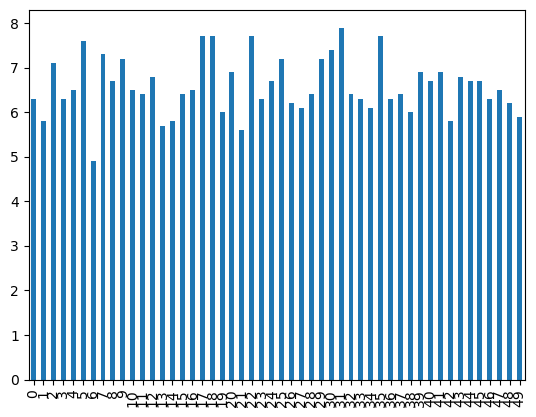

In [ ]:
sepal_all.merge(virginica,on='Id')['SepalLengthCm'].plot(kind='bar')

In [ ]:
petal_all

,Unnamed: 0,Id,PetalLengthCm,PetalWidthCm
0,0,1,1.4,0.2
1,1,2,1.4,0.2
2,2,3,1.3,0.2
3,3,4,1.5,0.2
4,4,5,1.4,0.2
...,...,...,...,...
145,145,146,5.2,2.3
146,146,147,5.0,1.9
147,147,148,5.2,2.0
148,148,149,5.4,2.3


<Axes: >

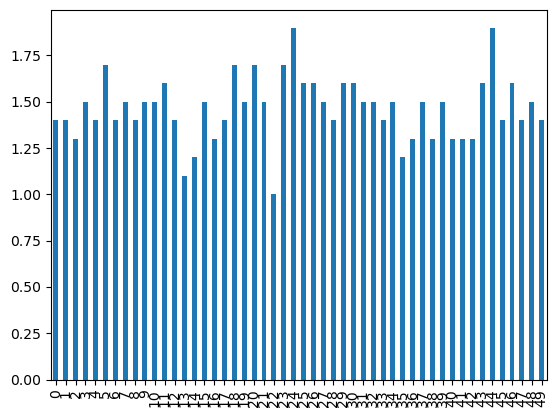

In [ ]:
petal_all.merge(setosa,on='Id')['PetalLengthCm'].plot(kind='bar')

### `Q-10:` Create the complete dataset by uisng the below datasets:
- virginica
- versicolor
- setosa
- sepal all
- petal all

This dataset should have these below column names in order:
1. Id
2. Species
3. SepalLengthCm
4. SepalWidthCm
5. PetalLengthCm
6. PetalWidthCm

Also, the dataset should be shuffled means the `Id` column should not be in increasing or decreasing order. So, make a dataset which has the shuffled Id column. You can use `DataFrame.sample()` method to shuffle.

In [ ]:
# how to merge multiple dataframe with one coloumns 
flower_df = sepal_all.merge(petal_all,on='Id').merge(virginica,on='Id').merge(versicolor,on='Id').merge(setosa,on='Id')
flower_df

In [ ]:
from functools import reduce
import pandas as pd

# List of all DataFrames
dfs = [sepal_all, petal_all, virginica, versicolor, setosa]
merged_df = reduce(lambda left, right: left.merge(right, on='Id', suffixes=('', '_dup')), dfs)

# Merge all DataFrames on 'Id'
merged_df = reduce(lambda left, right: left.merge(right, on='Id'), dfs)


In [ ]:
dfs = [df.drop(columns=["Unnamed: 0"], errors="ignore") for df in [sepal_all, petal_all, virginica, versicolor, setosa]]
dfs

[      Id  SepalLengthCm  SepalWidthCm
 0      1            5.1           3.5
 1      2            4.9           3.0
 2      3            4.7           3.2
 3      4            4.6           3.1
 4      5            5.0           3.6
 ..   ...            ...           ...
 145  146            6.7           3.0
 146  147            6.3           2.5
 147  148            6.5           3.0
 148  149            6.2           3.4
 149  150            5.9           3.0
 
 [150 rows x 3 columns],
       Id  PetalLengthCm  PetalWidthCm
 0      1            1.4           0.2
 1      2            1.4           0.2
 2      3            1.3           0.2
 3      4            1.5           0.2
 4      5            1.4           0.2
 ..   ...            ...           ...
 145  146            5.2           2.3
 146  147            5.0           1.9
 147  148            5.2           2.0
 148  149            5.4           2.3
 149  150            5.1           1.8
 
 [150 rows x 3 columns],
      Id  

,Unnamed: 0,Id,SepalLengthCm,SepalWidthCm,Unnamed: 0_dup,PetalLengthCm,PetalWidthCm,Unnamed: 0_dup,Species,Unnamed: 0_dup,Species_dup,Unnamed: 0_dup,Species_dup


### `Q-11:` Find out the maximum and minimum sepal width and petal width of Setosa and Versicolor. To do this:
- First create a dataset with merging the required datasets
- After that, use `groupby` to create groups based on the "Species" column.
- Then find out which are asked in this question.


The output should be like this:
```bash
Minimum Sepal width of Setosa is 2.3
Maximum Sepal width of Setosa is 4.4

**************************************************

Minimum Sepal width of Versicolor is 2.0
Maximum Sepal width of Versicolor is 3.4

**************************************************
```

In [ ]:
# code here